Classical Vs. Quantum Random Walks - 


In [ ]:
# Import libraries 

import random 
import matplotlib.pyplot as plt
import numpy as np

 Standard Deviation: 7.352805178977612


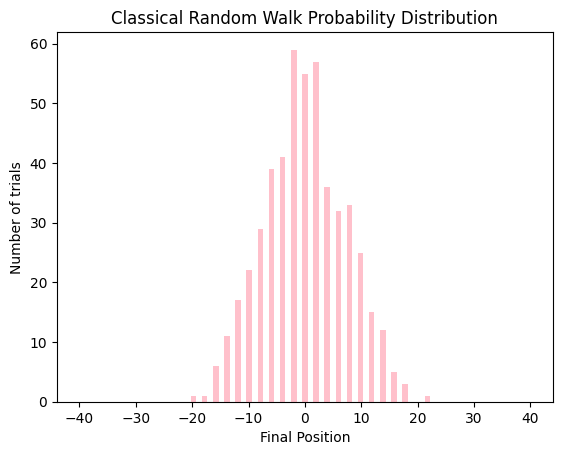

In [ ]:
# Classical Random Walk Simulator 

# Initialize steps and samples 
n_steps = 50 
n_samples = 500 

# Simulate the random walk 
final_positions = [] 
for sample in range(n_samples): 
    position = 0 
    for step in range(n_steps): 
        position += random.choice([-1, 1])
    final_positions.append(position)

# Calculate & print the standard deviation 
standard_dev = np.std(final_positions)
print(f" Standard Deviation: {standard_dev}")

# Plot the probability distribution 
plt.hist(final_positions, range=(-40, 40), bins=81, color="pink")
plt.title('Classical Random Walk Probability Distribution')
plt.xlabel('Final Position')
plt.ylabel('Number of trials')
plt.show()


 Standard Deviation: 27.267251860061


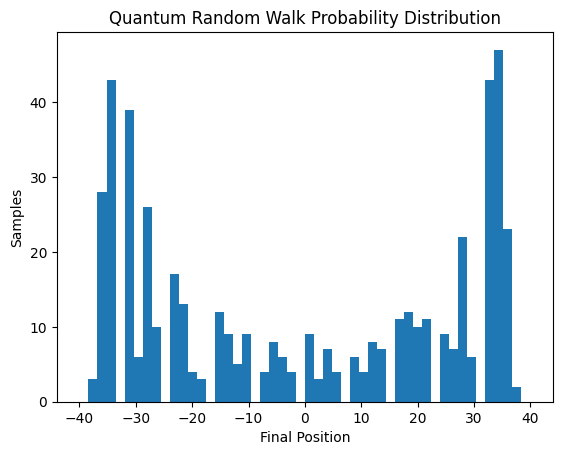

In [38]:
# Quantum Random Walk Simulator 

# Parameter Initialization 
positions = 151 # Necessary to determine the size of the position statevector 
samples = 500 
center = positions // 2

# Create the Hadamard Gate for superposition 
H = (1/np.sqrt(2)) * np.array([[1, 1],[1, -1]])

def run_single_walk(steps): 
    # Create the coin state of the amplitude of each side of the coin 
    coin_state = (1/np.sqrt(2)) * np.array([1, 1j]) 

    # Create the position state of the amplitude of each position
    position_state = np.zeros(positions)
    position_state[center] = 1  # Sets the center to 100% probability 

    # Statevector of the amplitudes of each coin side at each specific position
    state = np.kron(coin_state, position_state) 

    # Apply the shift operator 
    for step in range(steps): 
        new_state = np.zeros_like(state, dtype=complex) 

        for pos in range(positions): 
            for coin in [0, 1]: # 0 as heads, 1 as tails 
                index = coin * positions + pos 
                amp = state[index] 

                if abs(amp) > 0: 
                    for new_coin in [0, 1]:
                        # Gives how much of the coin flows into the new coin state after H
                        coin_amp = H[new_coin, coin] * amp 

                        # 0 is moving left, 1 is moving right 
                        if new_coin == 0 and pos > 0: 
                            new_index = new_coin * positions + (pos - 1)
                        elif new_coin == 1 and pos < positions - 1: 
                            new_index = new_coin * positions + (pos + 1)
                        new_state[new_index] += coin_amp
        state = new_state 

    # Add the probabilities of the state vector together by squaring the amplitude 
    # Note: the probabilities when summed, should equal 1 to be normalized!
    prob = np.zeros(positions) 
    for pos in range(positions): 
        for coin in [0, 1]: 
            index = coin * positions + pos
            prob[pos] += abs(state[index])**2 
            
    # Measure the system to collapse its state 
    return np.random.choice(range(positions), p=prob)

# Run multiple samples 
results = []
for sample in range(samples): 
    final_position = run_single_walk(50) 
    results.append(final_position - center)

# Calculate the standard deviation 
standard_dev = np.std(results)
print(f" Standard Deviation: {standard_dev}")

# Plot the graph using Matplotlib
plt.hist(results, range=(-40, 40), bins=50)
plt.title("Quantum Random Walk Probability Distribution")
plt.xlabel("Final Position")
plt.ylabel("Samples")
plt.show()
    


In [ ]:
# The quantum RW runtime for searching for a target node on a 1D ring
def quantum_runtime(n_nodes, samples=500):
    runtimes = []
    target = random.randint(0, n_nodes - 1) # Randomly select a target node
    H = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]]) # Initiate the Hadamard gate matrix 

    for sample in range(samples): 
        # Initialize the start position & steps
        start_position = 0
        steps = 0

        # Create the coin and position statevectors 
        coin_state = (1/np.sqrt(2)) * np.array([1, 1j])
        position_state = np.zeros(n_nodes)
        position_state[start_position] = 1 # Sets probability to 100% at start
        
        # Take the tensor product of the position state and coin state 
        state = np.kron(coin_state, position_state)
        measurement = -1   # Initialize a measurement variable to end the loop 
        
        # End the while loop when the measured position is at the target node
        while measurement != target: 
            steps += 1 # Add a step every movement taken

            # Calculate the coin amplitude and apply the shift operation 
            new_state = np.zeros_like(state, dtype=complex)

            for node in range(n_nodes): 
                for side in [0, 1]: 
                    amp = state[side*n_nodes + node]

                    # Apply the Hadamard matrix based off the coin and new coin
                    for new_coin in [0, 1]: 
                        #calculate the amplitude of that coin side 
                        coin_amp = H[new_coin, side] * amp

                        # Moves left if 0, right if 1 
                        if new_coin == 0: 
                            new_position = (node - 1) % n_nodes 
                        else: 
                            new_position = (node + 1) % n_nodes
                        
                        # Update the new_state by adding the new coin amplitude 
                        new_state[new_coin*n_nodes + new_position] += coin_amp

            state = new_state 

            # Create a probability vector 
            probabilities = np.zeros(n_nodes)
            for node in range(n_nodes): 
                for side in [0, 1]: 
                    # square the ampltiudes in the state to get the probabilities; add to probability 
                    probabilities[node] += abs(state[side*n_nodes + node])**2

            # Measure to collapse the state to a position given the probabilities 
            measurement = np.random.choice(range(n_nodes), p=probabilities)
        
        # Add the runtime once we reach the target node 
        runtimes.append(steps)
    return runtimes, np.mean(runtimes)

In [11]:
# The classical RW runtime for searching for a target node on a 1D ring
def classical_runtime(n_nodes, samples=500): 
    runtimes = []
    target = random.randint(0, n_nodes - 1) # Randomly chooses a target 

    # Perform many samples 
    for sample in range(samples):
        # Initialize position and steps  
        position = 0 
        steps = 0

        # Randomly move until we reach the target node 
        while position != target: 
            movement = random.choice([-1, 1])
            position = (position + movement) % n_nodes # Update the position
            steps += 1 # Increase steps every movement 
        runtimes.append(steps)

    return runtimes, np.mean(runtimes)

Nodes = 10: Classical Mean = 16.23, Quantum Mean = 5.37


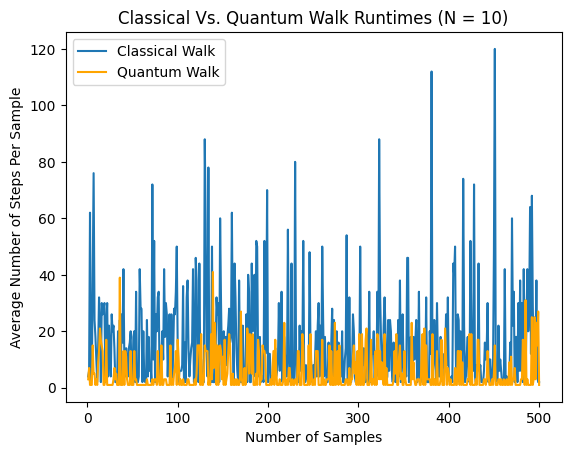

Nodes = 20: Classical Mean = 50.28, Quantum Mean = 23.47


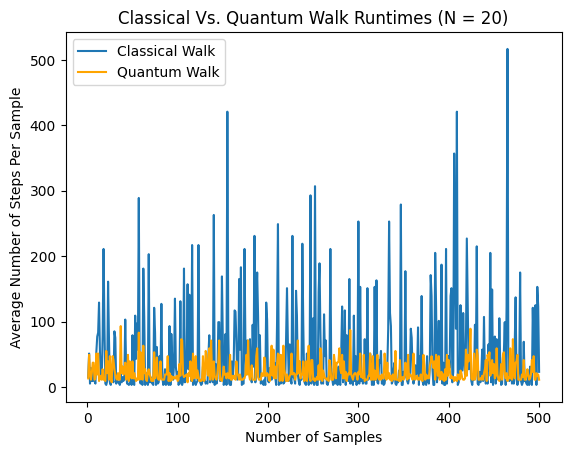

Nodes = 30: Classical Mean = 159.38, Quantum Mean = 28.72


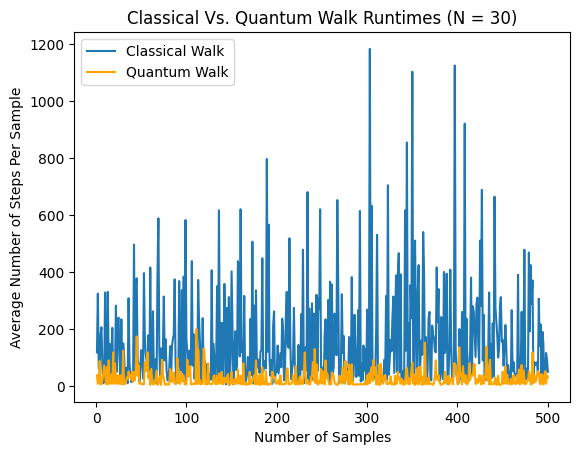

Nodes = 40: Classical Mean = 333.02, Quantum Mean = 46.09


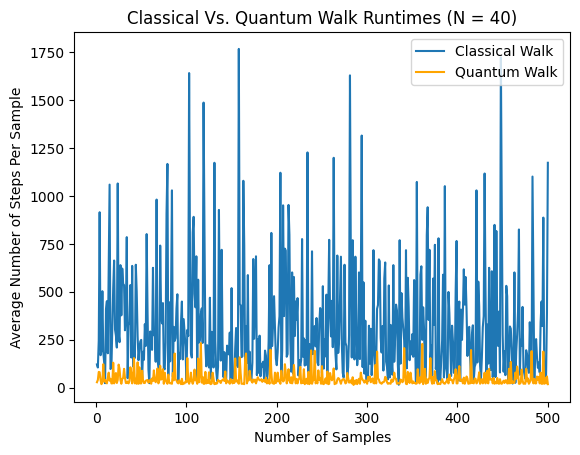

In [ ]:
# Testing out different N nodes for comparison
for node in [10, 20, 30, 40]: 
    crun, c = classical_runtime(node)
    samples = np.linspace(1, 500, 500)
    qrun, q = quantum_runtime(node)

    # print the general means of each search algorithm 
    print(f"Nodes = {node}: Classical Mean = {c:.2f}, Quantum Mean = {q:.2f}")
    
    # Plot the classical vs quantum runtimes 
    plt.plot(samples, crun, label='Classical Walk')
    plt.plot(samples, qrun, label='Quantum Walk', color='orange')
    plt.title(f'Classical Vs. Quantum Walk Runtimes (N = {node})')
    plt.xlabel('Number of Samples')
    plt.ylabel('Average Number of Steps Per Sample')
    plt.legend()
    plt.show()


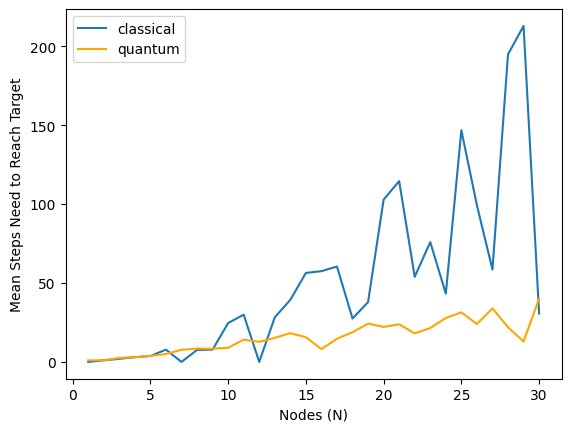

In [ ]:
node_30 = np.arange(1, 31)
classical = []
quantum = [] 
for node in node_30:  
    crun, c = classical_runtime(node)
    qrun, q = quantum_runtime(node)
    classical.append(c)
    quantum.append(q)

plt.plot(node_30, classical, label='Classical')
plt.plot(node_30, quantum, label='Quantum', color='orange')
plt.xlabel('Nodes (N)')
plt.ylabel('Mean Steps Need to Reach Target')
plt.legend()
plt.show()